In [1]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/reviews_clean.parquet"
)

print(df.shape)
df.head()

(29576, 7)


,review_id,review,voted_up,votes_up,review_date,refunded,playtime_hours
0,232591722,this game is good yes but if you have a bad wi...,False,0,2026-08-11,False,26.4
1,232591709,game crashed when anticheat is launched... spe...,False,0,2026-08-11,False,52.8
2,232591636,balls,True,0,2026-08-11,False,11.4
3,232591267,♥♥♥♥ game.,False,0,2026-08-11,False,165.6
4,232588494,buggy piece of ♥♥♥♥,False,0,2026-08-11,False,43.2


In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 29576 entries, 0 to 29577
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   review_id       29576 non-null  int64  
 1   review          29576 non-null  str    
 2   voted_up        29576 non-null  bool   
 3   votes_up        29576 non-null  int64  
 4   review_date     29576 non-null  str    
 5   refunded        29576 non-null  bool   
 6   playtime_hours  29576 non-null  float64
dtypes: bool(2), float64(1), int64(2), str(2)
memory usage: 5.3 MB


In [3]:
df.describe()

,review_id,votes_up,playtime_hours
count,2.957600e+04,29576.000000,29576.000000
mean,2.197293e+08,1.311131,73.211787
std,9.120166e+06,19.446466,137.399555
min,2.046553e+08,0.000000,0.000000
25%,2.118171e+08,0.000000,9.000000
50%,2.209275e+08,0.000000,27.000000
75%,2.284605e+08,0.000000,78.600000
max,2.325917e+08,1447.000000,3525.000000


In [4]:
df.isna().sum()

review_id         0
review            0
voted_up          0
votes_up          0
review_date       0
refunded          0
playtime_hours    0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.to_csv("../data/processed/reviews.csv")
df.to_parquet("../data/processed/reviews_clean.parquet")

In [7]:
df.isna().sum()

review_id         0
review            0
voted_up          0
votes_up          0
review_date       0
refunded          0
playtime_hours    0
dtype: int64

In [8]:
(df["voted_up"].value_counts(normalize=True) * 100).round(1)

voted_up
True     50.7
False    49.3
Name: proportion, dtype: float64

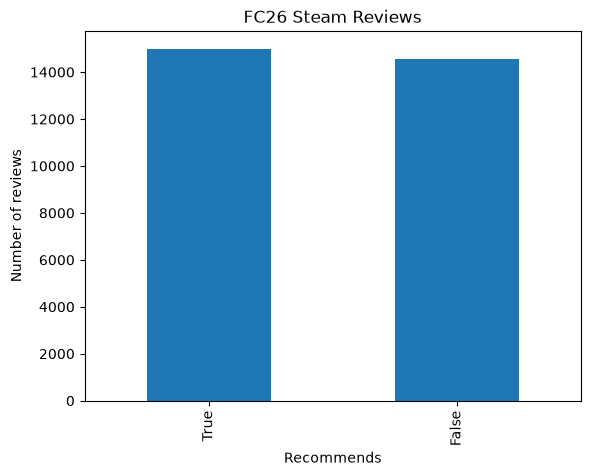

In [9]:
import matplotlib.pyplot as plt
df["voted_up"].value_counts().plot(
    kind="bar"
)

plt.title("FC26 Steam Reviews")
plt.xlabel("Recommends")
plt.ylabel("Number of reviews")
plt.show()

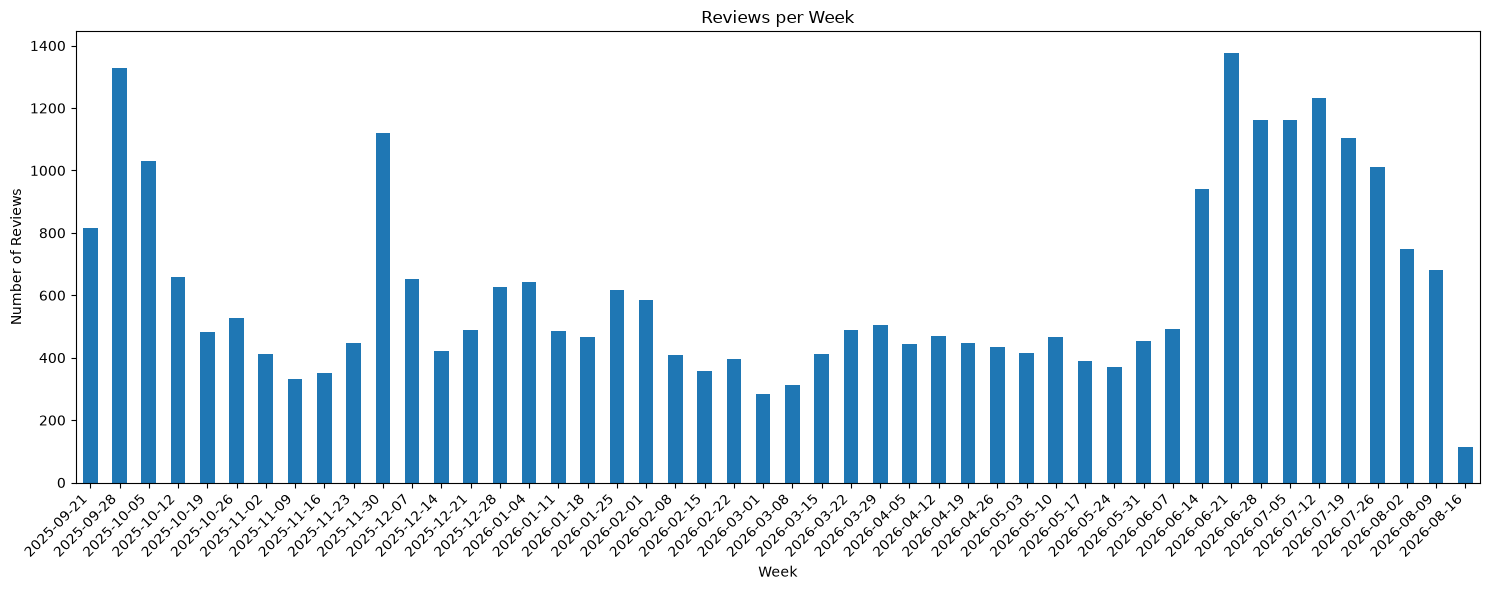

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Convert to pandas datetime
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['review_date'])

# Count reviews per week
weekly_reviews = (
    df
    .set_index('review_date')
    .resample('W')
    .size()
)

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

weekly_reviews.plot(kind='bar', ax=ax)

ax.set_xlabel('Week')
ax.set_ylabel('Number of Reviews')
ax.set_title('Reviews per Week')

# Remove the time from x-axis labels
ax.set_xticklabels(
    [date.strftime('%Y-%m-%d') for date in weekly_reviews.index],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

In [11]:
df["playtime_hours"].describe()

count    29576.000000
mean        73.211787
std        137.399555
min          0.000000
25%          9.000000
50%         27.000000
75%         78.600000
max       3525.000000
Name: playtime_hours, dtype: float64

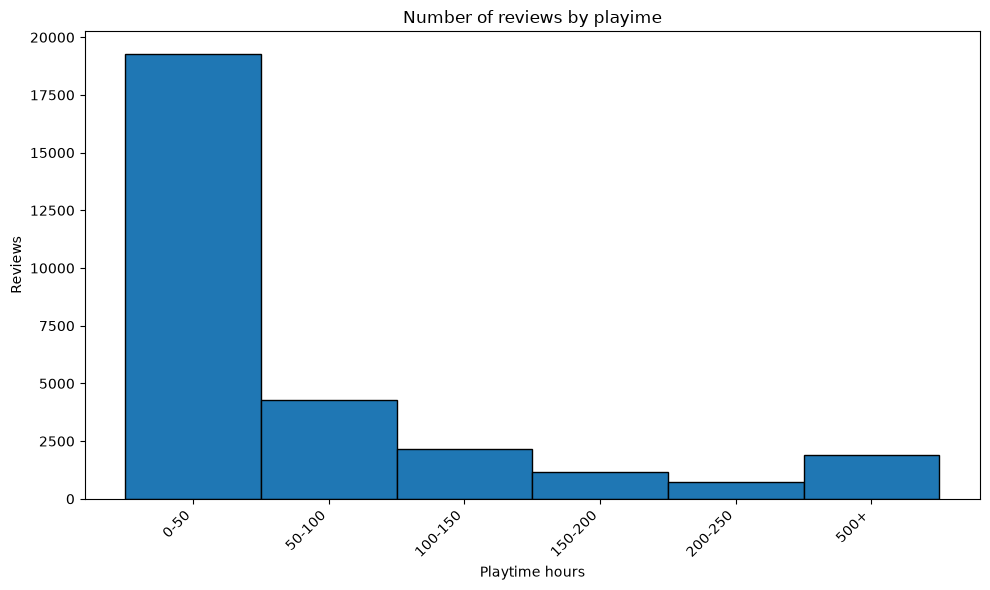

In [72]:
col = df['playtime_hours']  # replace with your actual column name

# 1. define bin edges: 0, 50, 100, ..., 500
bin_edges = list(range(0, 350, 50))  # [0, 50, 100, ..., 500]

# 2. clip values above 500 down to 500 so they all land in the last bin
clipped = col.clip(upper=300)

# 3. plot histogram using these edges
fig, ax = plt.subplots(figsize=(10, 6))
counts, edges, patches = ax.hist(clipped, bins=bin_edges, edgecolor='black')

# 4. fix the x-tick labels so the last bin reads "500+"
labels = [f"{int(edges[i])}-{int(edges[i+1])}" for i in range(len(edges)-1)]
labels[-1] = "500+"

ax.set_xticks([(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)])
ax.set_xticklabels(labels, rotation=45, ha='right')

ax.set_xlabel("Playtime hours")
ax.set_ylabel("Reviews")
ax.set_title("Number of reviews by playime")
plt.tight_layout()
plt.show()

In [64]:
df.head(10)

,review_id,review,voted_up,votes_up,review_date,refunded,playtime_hours,playtime_bucket
7837,228284511,very good,True,0,2026-06-18,False,3525.0,100h+
28583,205005446,(dont ask about my play time i never close thi...,True,0,2025-09-23,False,2851.8,100h+
8116,228183046,GOOD,True,0,2026-06-17,False,2352.0,100h+
10549,226264252,good,True,1,2026-05-23,False,2307.6,100h+
9870,227116764,cool game. very sweaty,True,0,2026-06-03,False,2139.0,100h+
3109,230605751,horrible game,False,0,2026-07-16,False,2132.4,100h+
5295,229512600,"Dear developers of this stupid, pointless game...",False,0,2026-07-03,False,2124.6,100h+
3668,230335498,Abject filth meant to push even further the co...,False,0,2026-07-12,False,2109.6,100h+
4456,229959463,"Best FC, best FiFA sice 17",True,0,2026-07-08,False,1851.0,100h+
11370,225079759,BEST GAME 4EVER BUT MY LUCK SO BAD I'M OPEN PA...,True,0,2026-05-09,False,1841.4,100h+


In [66]:
print(df["review"][11370])

BEST GAME 4EVER BUT MY LUCK SO BAD I'M OPEN PACK 89X7 I GOT VAN DIJK  GOLD NOT TOTS


In [67]:
top_upvoted = df.sort_values(by="votes_up", ascending=False)

In [75]:
top_upvoted.head(10)

,review_id,review,voted_up,votes_up,review_date,refunded,playtime_hours,playtime_bucket
20050,214316627,"If you buy the game at full price, you're an i...",False,1447,2025-12-27,False,27.6,25–50h
8849,227902419,"If you're purchasing for the World Cup, DO NOT...",False,1324,2026-06-13,False,1.2,0–2h
28109,205228221,Absolute disgrace of a game. Every single year...,False,725,2025-09-26,False,0.6,0–2h
20391,213992622,EA FC 26 is a straight-up SCAM.\n\nThis is han...,False,723,2025-12-23,False,34.8,25–50h
21784,212505107,Absolute garbage. I refuse to believe actual h...,False,670,2025-12-03,False,5.4,5–10h
27717,205336115,I had a rule where I would wait every other ye...,False,646,2025-09-27,True,1.2,0–2h
9968,226985902,Just wanted to kick a ball around. How hard ca...,False,619,2026-06-02,False,4.2,2–5h
19700,214667052,this game is so bad it made me appreciate time...,True,606,2025-12-30,False,75.0,50–100h
11185,225313253,I mainly play FC 26 for the career mode and ye...,False,452,2026-05-12,False,133.8,100h+
28251,205185468,The game is basically unplayable on PC. Most o...,False,436,2025-09-25,False,33.6,25–50h


In [83]:
#this is to put back in order they were made
df =  df.sort_values(by="review_date", ascending=False)
df.head()

,review_id,review,voted_up,votes_up,review_date,refunded,playtime_hours,playtime_bucket
38,232550789,ggg,True,0,2026-08-11,False,4.2,2–5h
1,232591709,game crashed when anticheat is launched... spe...,False,0,2026-08-11,False,52.8,50–100h
13,232577462,"just download FIFA 17, don't buy this sht",False,0,2026-08-11,False,6.0,5–10h
32,232555566,It is fun to play but i request ea to fix the ...,True,0,2026-08-11,False,4.8,2–5h
24,232566465,bolehla,True,0,2026-08-11,False,35.4,25–50h
